# Project Overview: Context-Aware IRI Prediction from Vehicle Telemetry

This notebook presents a complete machine learning pipeline for predicting the International Roughness Index (IRI) using raw vehicle telemetry data. The primary objective is to map temporal sensor readings into a structured spatial domain and train an optimized neural network suitable for mobile edge deployment. 

### Key Components

* **Data Preprocessing and Augmentation:** The pipeline extracts raw IMU and speed data, converts it from a time-based format to a fixed spatial grid of 5-meter windows, and applies targeted oversampling to balance extreme road conditions and rare events.
* **Dual-Branch Neural Network:** The core architecture features a 1D Convolutional Neural Network to extract spatial features from the raw sensor data. This is merged with a secondary dense network that processes contextual statistics, such as average speed and vehicle type.
* **Custom Objective Function:** The model is trained using a specialized loss function that combines Huber and Log-Cosh metrics. It includes domain-specific penalties to heavily penalize false positive predictions on smooth roads during heavy acceleration or low speeds.
* **Edge Optimization:** The trained model is quantized and converted to TensorFlow Lite format. This process reduces the memory footprint and accelerates inference speed for real-time execution on mobile devices.
* **Performance Evaluation:** The final section evaluates the model on an unseen test track. It calculates standard regression metrics (MAE, RMSE, R-squared) and visualizes prediction accuracy, residual distribution, and continuous spatial tracking performance.

windowing

In [1]:
import os
import numpy as np
import pandas as pd
import pywt
from scipy.interpolate import interp1d
from joblib import Parallel, delayed
import time


In [2]:
import os
import time
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from joblib import Parallel, delayed

# ==========================================
# Configuration & Constants
# ==========================================
BASE_DIR = "../../../../data/simulation/data/IRI"
LIMITS_FILE = "../reading_limits_new.txt" 

WINDOW_SIZE_M = 5.0
STEP_SIZE_M = 2.0 
FINAL_STEPS = 100 
TARGET_HZ_RATES = [5, 10, 15, 20, 25, 30] 

FEATURES = ['ax', 'ay', 'az', 'wx', 'wy', 'wz', 'speed_ms']

def parse_limits(filepath):
    """
    Parses reading limits and trip boundaries from the configuration file.
    """
    limits = {}
    current_trip = None
    
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        line = line.strip()
        if not line: continue
        
        if 'ml_model' in line:
            parts = line.split('\\')
            current_trip = f"{parts[-3]}/{parts[-2]}/{parts[-1]}"
            if current_trip not in limits:
                limits[current_trip] = []
        elif line.startswith('start:'):
            start_val = int(line.split(':')[1].strip())
        elif line.startswith('end:'):
            end_val = int(line.split(':')[1].strip())
            if current_trip:
                limits[current_trip].append((start_val, end_val))
                
    return limits

# ==========================================
# Core Processing Engine
# ==========================================
def process_trip_data(df, vehicle_name):
    """
    Processes raw telemetry data into standardized spatial windows.
    Handles distance conversion, resampling, and edge-case oversampling.
    """
    X_raw_list, X_ctx_list, y_list = [], [], []
    
    df = df.sort_values('sample_number').copy()
    df['time_s'] = df['sample_number'] * 0.01 
    df['dt'] = df['time_s'].diff().fillna(0.01)
    df['dx'] = df['speed_ms'] * df['dt']
    df['cumulative_distance'] = df['dx'].cumsum()
    
    max_dist = df['cumulative_distance'].max()
    
    for start_dist in np.arange(0, max_dist - WINDOW_SIZE_M, STEP_SIZE_M):
        end_dist = start_dist + WINDOW_SIZE_M
        patch = df[(df['cumulative_distance'] >= start_dist) & (df['cumulative_distance'] < end_dist)]
        
        if len(patch) < 15: continue 
        
        target_iri = patch['IRI'].mean()
        avg_speed_ms = patch['speed_ms'].mean()
        avg_speed_kmh = avg_speed_ms * 3.6

        # Filter out intermediate IRI values to balance the dataset distribution
        if target_iri < 2.0 and np.random.rand() < 0.70:
            continue 
            
        start_time = patch['time_s'].min()
        end_time = patch['time_s'].max()
        
        for target_hz in TARGET_HZ_RATES:
            poll_interval = 1.0 / target_hz
            t_polls = np.arange(start_time, end_time, poll_interval)
            t_polls += np.random.uniform(0, 0.02, size=len(t_polls)) 
            
            sabotaged_features = []
            for feat in FEATURES:
                os_sensor = interp1d(patch['time_s'], patch[feat], kind='previous', fill_value="extrapolate")
                sabotaged_features.append(os_sensor(t_polls))
            
            os_dist = interp1d(patch['time_s'], patch['cumulative_distance'], kind='linear', fill_value="extrapolate")
            sabotaged_dists = os_dist(t_polls)
            
            if len(sabotaged_dists) < 5: continue
            
            # Distance Domain Resampling
            fixed_spatial_grid = np.linspace(start_dist, end_dist, FINAL_STEPS)
            fixed_patch_features = []
            
            for i, feat in enumerate(FEATURES):
                spatial_fix = interp1d(sabotaged_dists, sabotaged_features[i], kind='linear', fill_value="extrapolate")
                fixed_patch_features.append(spatial_fix(fixed_spatial_grid))
                
            X_raw_filtered = np.column_stack(fixed_patch_features) 
            
            # Contextual Feature Extraction
            mcr_az = len(np.where(np.diff(np.sign(X_raw_filtered[:, 2])))[0]) / FINAL_STEPS
            veh_onehot = [1, 0, 0] if 'vivace' in vehicle_name else ([0, 1, 0] if 'sunburst' in vehicle_name else [0, 0, 1])
            X_ctx = np.array([avg_speed_ms, np.mean(X_raw_filtered[:, 2]), np.mean(X_raw_filtered[:, 1]), mcr_az] + veh_onehot)

            # Oversampling logic for critical edge cases
            multiplier = 1
            if avg_speed_kmh < 25 and target_iri < 2:
                multiplier = 10 
            elif avg_speed_kmh > 50 and target_iri > 5:
                multiplier = 10 
            
            for _ in range(multiplier):
                y_list.append(target_iri)
                X_raw_list.append(X_raw_filtered)
                X_ctx_list.append(X_ctx)
            
    return X_raw_list, X_ctx_list, y_list

# ==========================================
# Parallel Processing Router
# ==========================================
def worker_process_trip(trip_key, ranges):
    """
    Worker function to load and process individual trips.
    Maps trips to train/test splits based on predefined criteria.
    """
    parts = trip_key.split('/')
    vehicle, map_name, trip_name = parts[0], parts[1], parts[2]
    
    csv_path = os.path.join(BASE_DIR, vehicle, map_name, trip_name, 'readings.csv')
    if not os.path.exists(csv_path):
        return None 
        
    df = pd.read_csv(csv_path)
    
    valid_rows = pd.DataFrame()
    for (start_idx, end_idx) in ranges:
        segment = df[(df['sample_number'] >= start_idx) & (df['sample_number'] <= end_idx)]
        valid_rows = pd.concat([valid_rows, segment])
        
    if valid_rows.empty: 
        return None
        
    x_r, x_c, y_val = process_trip_data(valid_rows, vehicle)
    
    # Dataset Splitting Logic
    split = 'train' 

    if map_name == 'automation_test_track':
        if trip_name == 'trip_1':
            split = 'train'
        elif trip_name == 'trip_2' and ('vivace' in vehicle or 'sunburst' in vehicle):
            split = 'test'
        elif 'hopper' in vehicle and trip_name in ['trip_2', 'trip_3']:
            split = 'test'
            
    print(f"[INFO] Processed {trip_key} | Split: {split.upper()} | Samples: {len(y_val)}")
    return {
        'split': split,
        'raw': x_r,
        'ctx': x_c,
        'y': y_val
    }

def extract_all_data_parallel():
    """
    Executes data extraction across all authorized CPU cores.
    Compiles raw data, context arrays, and targets into standardized dictionaries.
    """
    limits_dict = parse_limits(LIMITS_FILE)
    
    datasets = {
        'train': {'raw': [], 'ctx': [], 'y': []},
        'val':   {'raw': [], 'ctx': [], 'y': []},
        'test':  {'raw': [], 'ctx': [], 'y': []}
    }
    
    print(f"[INFO] Launching parallel extraction for {len(limits_dict)} trips...")
    start_time = time.time()
    
    results = Parallel(n_jobs=-1, backend="loky")(
        delayed(worker_process_trip)(trip_key, ranges) 
        for trip_key, ranges in limits_dict.items()
    )
    
    for res in results:
        if res is None: continue 
        split = res['split']
        datasets[split]['raw'].extend(res['raw'])
        datasets[split]['ctx'].extend(res['ctx'])
        datasets[split]['y'].extend(res['y'])

    # Format arrays
    for split in ['train', 'val', 'test']:
        datasets[split]['raw'] = np.array(datasets[split]['raw'])
        datasets[split]['ctx'] = np.array(datasets[split]['ctx'])
        datasets[split]['y'] = np.array(datasets[split]['y'])
        
        print(f"\n{split.upper()} SET:")
        print(f"  Raw Shape: {datasets[split]['raw'].shape}")
        print(f"  Ctx Shape: {datasets[split]['ctx'].shape}")
        
    print(f"\n[INFO] Total Processing Time: {time.time() - start_time:.2f} seconds")
    return datasets

# Execute pipeline
processed_data = extract_all_data_parallel()

X_train_raw = processed_data['train']['raw']
X_train_ctx = processed_data['train']['ctx']
y_train = processed_data['train']['y']

X_test_raw = processed_data['test']['raw']
X_test_ctx = processed_data['test']['ctx']
y_test = processed_data['test']['y']

# Validation set assignment
X_val_raw = np.copy(X_test_raw)
X_val_ctx = np.copy(X_test_ctx)
y_val = np.copy(y_test)

print("\n[INFO] Data extraction and pipeline compilation complete.")

[INFO] Launching parallel extraction for 19 trips...

TRAIN SET:
  Raw Shape: (88865, 100, 7)
  Ctx Shape: (88865, 7)

VAL SET:
  Raw Shape: (0,)
  Ctx Shape: (0,)

TEST SET:
  Raw Shape: (13412, 100, 7)
  Ctx Shape: (13412, 7)

[INFO] Total Processing Time: 55.99 seconds

[INFO] Data extraction and pipeline compilation complete.


model training pipeline

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D, GlobalMaxPooling1D, Dense, Concatenate, Dropout, BatchNormalization, DepthwiseConv1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ==========================================
# Custom Objective Function
# ==========================================
def context_aware_iri_loss(y_true_augmented, y_pred):
    """
    Custom loss function incorporating Huber loss, Log-Cosh, and domain-specific penalties.
    y_true_augmented shape: (batch, 3) -> [Actual_IRI, Speed, Acceleration]
    """
    # 1. Extract target and contextual variables
    y_true = y_true_augmented[:, 0:1]  
    speed = y_true_augmented[:, 1:2]   
    accel = y_true_augmented[:, 2:3]   

    error = y_true - y_pred
    abs_error = tf.abs(error)
    delta = 1.0  
    
    # 2. Base Huber Loss Calculation
    huber_loss = tf.where(abs_error <= delta, 
                          0.5 * tf.square(error), 
                          delta * (abs_error - 0.5 * delta))
    
    # 3. High-IRI (Pothole) Penalty Weighting
    high_iri_penalty = tf.where(y_true > 4.0, 3.0, 1.0) 
    
    # 4. Contextual False-Positive Penalty
    # Penalizes the model heavily if it predicts high IRI on smooth roads at low speeds/hard accelerations
    is_smooth = y_true < 2.0
    is_slow = speed < 5.56      
    is_hallucinating = y_pred > 2.0
    is_hard_accel = tf.abs(accel) > 2.5
    
    false_alarm = tf.cast(is_smooth & (is_slow | is_hard_accel) & is_hallucinating, tf.float32)
    context_penalty = 1.0 + (false_alarm * 5.0) 
    
    log_cosh = tf.math.log(tf.math.cosh(error))
    
    # 5. Aggregate Total Loss
    total_loss = (huber_loss + 0.2 * log_cosh) * high_iri_penalty * context_penalty
    return tf.reduce_mean(total_loss)

# ==========================================
# Neural Network Architecture
# ==========================================
def build_iri_model():
    """
    Constructs a dual-input deep neural network combining a 1D-CNN for spatial features 
    with a dense branch for contextual statistics.
    """
    # Branch 1: Spatial Feature Extraction (IMU & Speed Timeseries)
    input_raw = Input(shape=(100, 7), name="raw_imu_speed")
    
    x = DepthwiseConv1D(kernel_size=5, depth_multiplier=2, activation='relu', padding='same')(input_raw)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    
    x = GlobalMaxPooling1D(name="cnn_features")(x)    
    x = Dropout(0.3)(x) 
    
    # Branch 2: Contextual Dense Network (Aggregated Stats)
    input_ctx = Input(shape=(7,), name="context_stats")
    
    y = Dense(32, activation='relu')(input_ctx)
    y = BatchNormalization()(y)
    y = Dropout(0.2)(y)
    
    # Feature Fusion Layer
    merged = Concatenate(name="fusion_layer")([x, y])
    
    z = Dense(64, activation='relu')(merged)
    z = Dropout(0.2)(z)
    z = Dense(32, activation='relu')(z)
    
    output_iri = Dense(1, activation='relu', name="predicted_iri")(z)
    
    model = Model(inputs=[input_raw, input_ctx], outputs=output_iri)
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss=context_aware_iri_loss, 
                  metrics=['mae'])
    return model

# Initialize and compile the model
model = build_iri_model()
model.summary()

# Define training callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('best_iri_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

# ==========================================
# Target Augmentation & Training Execution
# ==========================================
print("\n[INFO] Compiling augmented targets for context-aware loss function...")

# Appending Context Feature Index 6 (Speed) and Index 2 (Acceleration) to target array
y_train_augmented = np.column_stack((y_train, X_train_ctx[:, 6], X_train_ctx[:, 2])) 
y_val_augmented = np.column_stack((y_val, X_val_ctx[:, 6], X_val_ctx[:, 2]))

print("\n[INFO] Initiating model training...")
history = model.fit(
    x=[X_train_raw, X_train_ctx], 
    y=y_train_augmented,                                       
    validation_data=([X_val_raw, X_val_ctx], y_val_augmented), 
    epochs=100,
    batch_size=64,
    callbacks=callbacks
)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 raw_imu_speed (InputLayer)     [(None, 100, 7)]     0           []                               
                                                                                                  
 depthwise_conv1d (DepthwiseCon  (None, 100, 14)     84          ['raw_imu_speed[0][0]']          
 v1D)                                                                                             
                                                                                                  
 batch_normalization (BatchNorm  (None, 100, 14)     56          ['depthwise_conv1d[0][0]']       
 alization)                                                                                       
                                                                                              

saving the model

In [4]:
import tensorflow as tf

# ==========================================
# TensorFlow Lite Export & Optimization
# ==========================================
def export_to_tflite(trained_model, output_filename='iri_background_model.tflite'):
    """
    Converts a trained Keras model to TensorFlow Lite format for edge deployment.
    Applies post-training dynamic range quantization to reduce the memory footprint 
    and accelerate inference on mobile CPUs with minimal degradation to accuracy.
    """
    print("\n[INFO] Initiating TensorFlow Lite conversion protocol...")
    
    # 1. Initialize converter with the trained model instance
    converter = tf.lite.TFLiteConverter.from_keras_model(trained_model)
    
    # 2. Apply Dynamic Range Quantization
    # Optimizes the model by converting float32 weights to 8-bit precision 
    # (or float16) where mathematically viable.
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    
    # 3. Execute compilation
    tflite_model = converter.convert()
    
    # 4. Serialize and save the optimized binary
    with open(output_filename, 'wb') as f:
        f.write(tflite_model)
        
    print(f"[INFO] Conversion successful. Quantized model saved to: {output_filename}")
    return output_filename

# Execute the conversion pipeline
tflite_file_path = export_to_tflite(model)


[INFO] Initiating TensorFlow Lite conversion protocol...


INFO:tensorflow:Assets written to: C:\Users\nishk\AppData\Local\Temp\tmpglaso6te\assets


INFO:tensorflow:Assets written to: C:\Users\nishk\AppData\Local\Temp\tmpglaso6te\assets


[INFO] Conversion successful. Quantized model saved to: iri_background_model.tflite


model evaulation


[INFO] Generating performance metrics and evaluation plots...
420/420 [==============================] - 3s 6ms/step
--- TEST SET PERFORMANCE ---
Mean Absolute Error (MAE): 0.3466 m/km
Root Mean Squared Error (RMSE): 1.2340 m/km
R-squared (R2 Score): 0.7443
[INFO] Plot suite saved successfully to iri_model_performance_evaluation.png


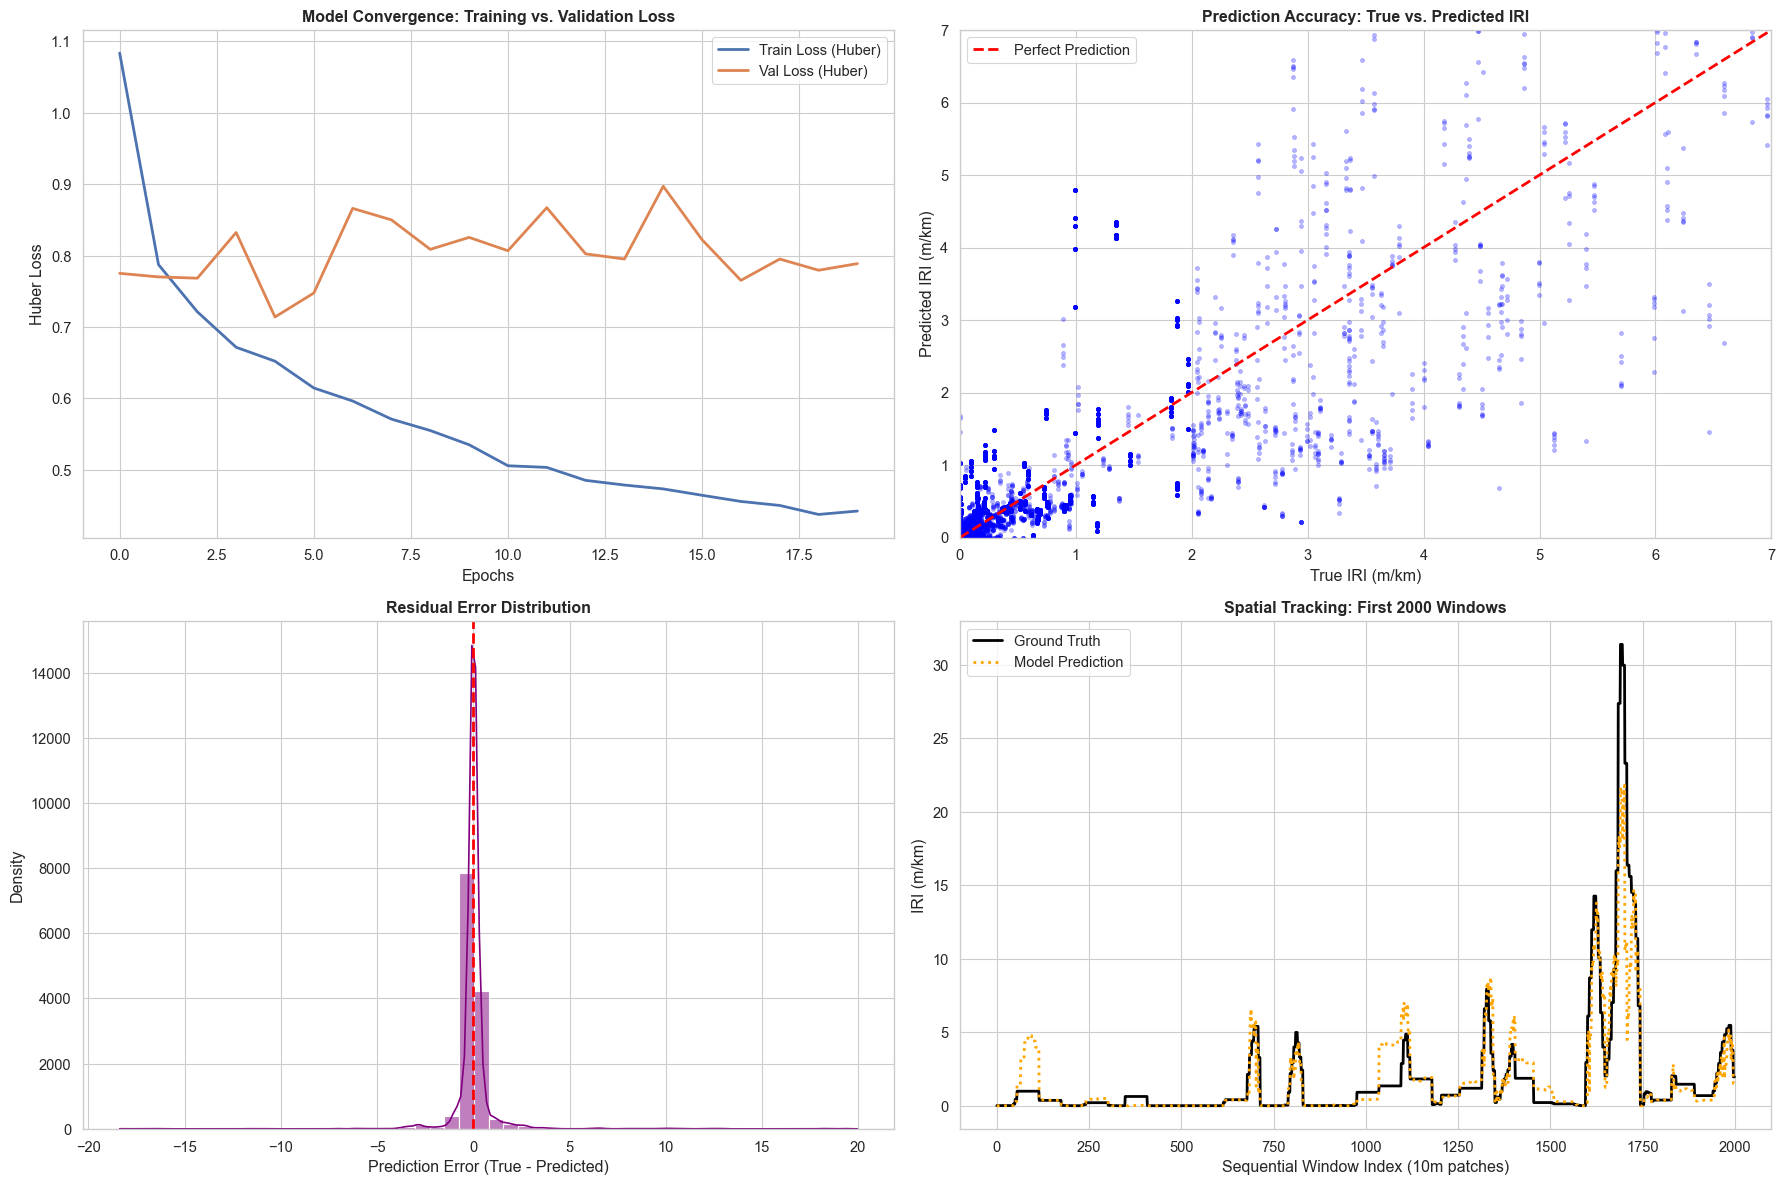

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# Model Evaluation & Metrics
# ==========================================
print("\n[INFO] Generating performance metrics and evaluation plots...")

# Execute predictions on the holdout test set
y_pred = model.predict([X_test_raw, X_test_ctx]).flatten()

# Calculate quantitative evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- TEST SET PERFORMANCE ---")
print(f"Mean Absolute Error (MAE): {mae:.4f} m/km")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} m/km")
print(f"R-squared (R2 Score): {r2:.4f}")

# ==========================================
# Data Visualization Suite
# ==========================================
# Configure seaborn for academic publication style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig = plt.figure(figsize=(18, 12))

# ------------------------------------------
# Plot 1: Training Convergence
# ------------------------------------------
ax1 = plt.subplot(2, 2, 1)
ax1.plot(history.history['loss'], label='Train Loss (Huber)', linewidth=2)
ax1.plot(history.history['val_loss'], label='Val Loss (Huber)', linewidth=2)
ax1.set_title("Model Convergence: Training vs. Validation Loss", fontweight='bold')
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Huber Loss")
ax1.legend()

# ------------------------------------------
# Plot 2: Actual vs. Predicted (Bounded)
# ------------------------------------------
ax2 = plt.subplot(2, 2, 2)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='blue', edgecolor=None, s=10, ax=ax2)

# Reference line for ideal predictions
ax2.plot([0, 7], [0, 7], color='red', linestyle='--', linewidth=2, label="Perfect Prediction")

# Constrain axes to standard IRI operational range
ax2.set_xlim(0, 7)
ax2.set_ylim(0, 7)

ax2.set_title("Prediction Accuracy: True vs. Predicted IRI", fontweight='bold')
ax2.set_xlabel("True IRI (m/km)")
ax2.set_ylabel("Predicted IRI (m/km)")
ax2.legend()

# ------------------------------------------
# Plot 3: Residual Error Distribution
# ------------------------------------------
ax3 = plt.subplot(2, 2, 3)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, bins=50, color='purple', ax=ax3)
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax3.set_title("Residual Error Distribution", fontweight='bold')
ax3.set_xlabel("Prediction Error (True - Predicted)")
ax3.set_ylabel("Density")

# ------------------------------------------
# Plot 4: Dynamic Tracking Over Distance
# ------------------------------------------
ax4 = plt.subplot(2, 2, 4)
# Visualizing a continuous segment of the test trip
plot_range = 2000
ax4.plot(y_test[:plot_range], label="Ground Truth", color='black', linewidth=2)
ax4.plot(y_pred[:plot_range], label="Model Prediction", color='orange', linestyle='dotted', linewidth=2)
ax4.set_title(f"Spatial Tracking: First {plot_range} Windows", fontweight='bold')
ax4.set_xlabel("Sequential Window Index (10m patches)")
ax4.set_ylabel("IRI (m/km)")
ax4.legend()

plt.tight_layout()
plt.savefig("iri_model_performance_evaluation.png", dpi=300)
print("[INFO] Plot suite saved successfully to iri_model_performance_evaluation.png")
plt.show()